In [1]:
print('Hello world')

Hello world


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicated row and no null values

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
print('categories in gender are :', end=" ")
print(df['gender'].nunique())

print('categories in race/ethnicity are :', end=" ")
print(df['race/ethnicity'].nunique())

print('categories in parental level of education  are :', end=" ")
print(df['parental level of education'].nunique())

print('categories in lunch are :', end=" ")
print(df['lunch'].nunique())

print('categories in test preparation course are :', end=" ")
print(df['test preparation course'].nunique())

categories in gender are : 2
categories in race/ethnicity are : 5
categories in parental level of education  are : 6
categories in lunch are : 2
categories in test preparation course are : 2


In [15]:
#define numerical and categorical features

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print('Numerical features : ')
print(numeric_features)
print()
print()
print('categorical features :')
print(categorical_features)

Numerical features : 
['math score', 'reading score', 'writing score']


categorical features :
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [16]:
# creating two new columns tot_score and avg

df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f'No. of students  with full marks in maths : {math_full}')
print(f'No. of students  with full marks in reading : {reading_full}')
print(f'No. of students  with full marks in writing : {writing_full}')

No. of students  with full marks in maths : 7
No. of students  with full marks in reading : 17
No. of students  with full marks in writing : 14


In [23]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()


print(f"No of student with less than 20 marks in reading :{reading_less_20}")
print(f"No of student with less than 20 marks in writing :{writing_less_20}")
print(f"No of student with less than 20 marks in math :{math_less_20}")


No of student with less than 20 marks in reading :1
No of student with less than 20 marks in writing :3
No of student with less than 20 marks in math :4


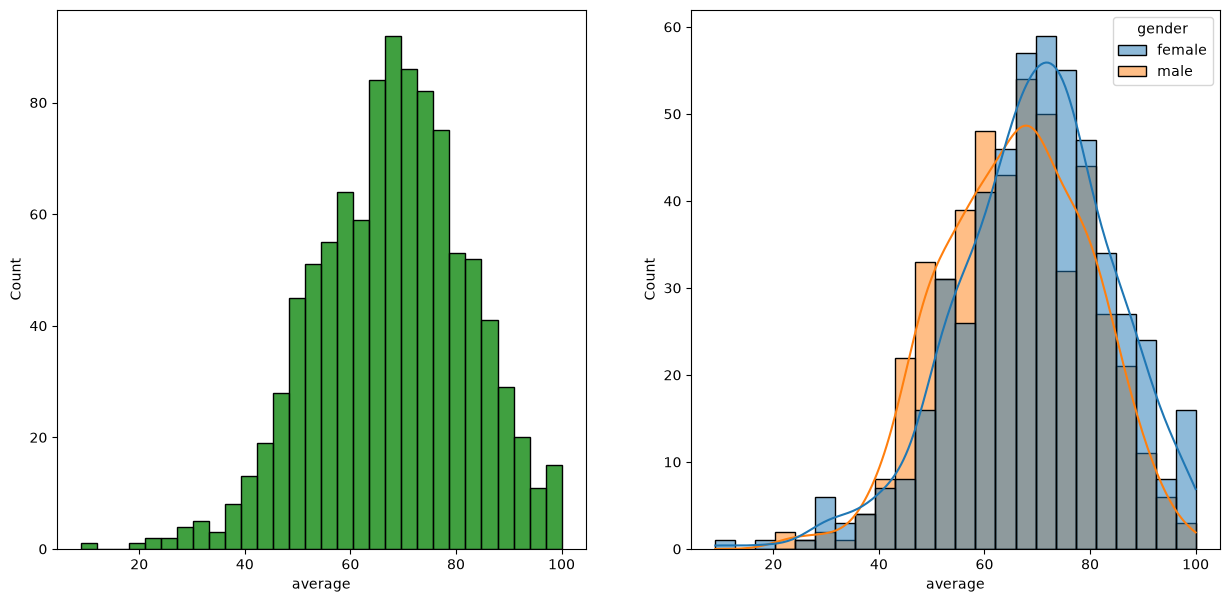

In [27]:
fig , axs = plt.subplots(1 , 2 ,figsize=(15 , 7))
plt.subplot(121)
sns.histplot(data=df , x = 'average' , bins=30 , color='g')
plt.subplot(122)
sns.histplot(data=df , x='average' , kde=True , hue='gender')
plt.show()